In [1]:
import pandas as pd

df=pd.read_csv('Travel.csv')
print(df.head())

   CustomerID  ProdTaken   Age    TypeofContact  CityTier  DurationOfPitch  \
0      200000          1  41.0     Self Enquiry         3              6.0   
1      200001          0  49.0  Company Invited         1             14.0   
2      200002          1  37.0     Self Enquiry         1              8.0   
3      200003          0  33.0  Company Invited         1              9.0   
4      200004          0   NaN     Self Enquiry         1              8.0   

       Occupation  Gender  NumberOfPersonVisiting  NumberOfFollowups  \
0        Salaried  Female                       3                3.0   
1        Salaried    Male                       3                4.0   
2     Free Lancer    Male                       3                4.0   
3        Salaried  Female                       2                3.0   
4  Small Business    Male                       2                3.0   

  ProductPitched  PreferredPropertyStar MaritalStatus  NumberOfTrips  \
0         Deluxe          

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [6]:
print(df.shape)
print(df.dtypes)
# Total memory usage with deep introspection
df.info(memory_usage="deep")

# Memory usage of each column in bytes
print(df.memory_usage(deep=True))

# Total memory usage in bytes
print(df.memory_usage(deep=True).sum())


(4888, 20)
CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 no

In [10]:
print(df.isnull().sum())

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64


In [12]:
import pandas as pd

students = pd.DataFrame({
    'roll_no': ['S01', 'S02', 'S03', 'S04', 'S05'],
    'name': ['Aarav', 'Bipana', 'Chirag', 'Dipesh', 'Esha'],
    'class': [10, 10, 9, 10, 9]
})

marks = pd.DataFrame({
    'roll_no': ['S01', 'S03', 'S04', 'S06'],
    'maths': [85, 92, 78, 88],
    'science': [90, 87, 82, 95]
})
#Combine the two DataFrames using pd.merge() with how='left' so that all students appear, 
# even if they have no marks recorded yet. Print the result and comment on what happens to students S02 and S05. 
merged_df = pd.merge(students, marks, on='roll_no', how='left')
print(merged_df)
# In the merged DataFrame, students S02 and S05 have NaN values for the 'maths' and 'science' columns because
#  they do not have corresponding entries in the marks DataFrame. This indicates that their marks are not recorded yet.

  roll_no    name  class  maths  science
0     S01   Aarav     10   85.0     90.0
1     S02  Bipana     10    NaN      NaN
2     S03  Chirag      9   92.0     87.0
3     S04  Dipesh     10   78.0     82.0
4     S05    Esha      9    NaN      NaN


In [14]:
#•	Now use pd.concat() to append the marks DataFrame below the students DataFrame (vertical concat). 
# Print it and explain in a comment why this usually doesn't make sense for this kind of data. 
concatenated_df = pd.concat([students, marks], ignore_index=True)
print(concatenated_df)
# This vertical concatenation doesn't make sense because the two DataFrames have different column structures.
# The students DataFrame has columns ['roll_no', 'name', 'class'], while the marks DataFrame has ['roll_no', 'maths', 'science'].
# Concatenating them results in a DataFrame with mismatched data in rows where the columns don't align, making it difficult to interpret.

  roll_no    name  class  maths  science
0     S01   Aarav   10.0    NaN      NaN
1     S02  Bipana   10.0    NaN      NaN
2     S03  Chirag    9.0    NaN      NaN
3     S04  Dipesh   10.0    NaN      NaN
4     S05    Esha    9.0    NaN      NaN
5     S01     NaN    NaN   85.0     90.0
6     S03     NaN    NaN   92.0     87.0
7     S04     NaN    NaN   78.0     82.0
8     S06     NaN    NaN   88.0     95.0


In [16]:
#•	Use pd.concat() again, but this time horizontally (axis=1). 
# Print the result and comment on the alignment of rows (which students get matched correctly and why some values become NaN).
horizontal_concat_df = pd.concat([students, marks], axis=1)
print(horizontal_concat_df)
# In the horizontal concatenation, the rows are aligned based on their index positions.
# The first five rows correspond to the students DataFrame, and the next four rows correspond to the marks DataFrame.
# Students S01, S03, and S04 get matched correctly because they appear in both DataFrames, 
# while S02 and S05 have NaN values for the marks columns because they do not have corresponding entries in the marks DataFrame. 
# Additionally, S06 has NaN values for the student information because it does not have a corresponding entry in the students DataFrame.

  roll_no    name  class roll_no  maths  science
0     S01   Aarav     10     S01   85.0     90.0
1     S02  Bipana     10     S03   92.0     87.0
2     S03  Chirag      9     S04   78.0     82.0
3     S04  Dipesh     10     S06   88.0     95.0
4     S05    Esha      9     NaN    NaN      NaN


In [17]:
#•	Summarize in your own words (2–3 lines): When should you use merge() instead of concat()?
# You should use merge() when you want to combine DataFrames based on a common key or column,
#  allowing for more control over how the data is combined (e.g., left, right, inner, outer joins).
# On the other hand, concat() is more suitable for simply stacking DataFrames 
# either vertically or horizontally without considering the relationships between the data,
#  which can lead to misaligned data if the structures of the DataFrames differ.


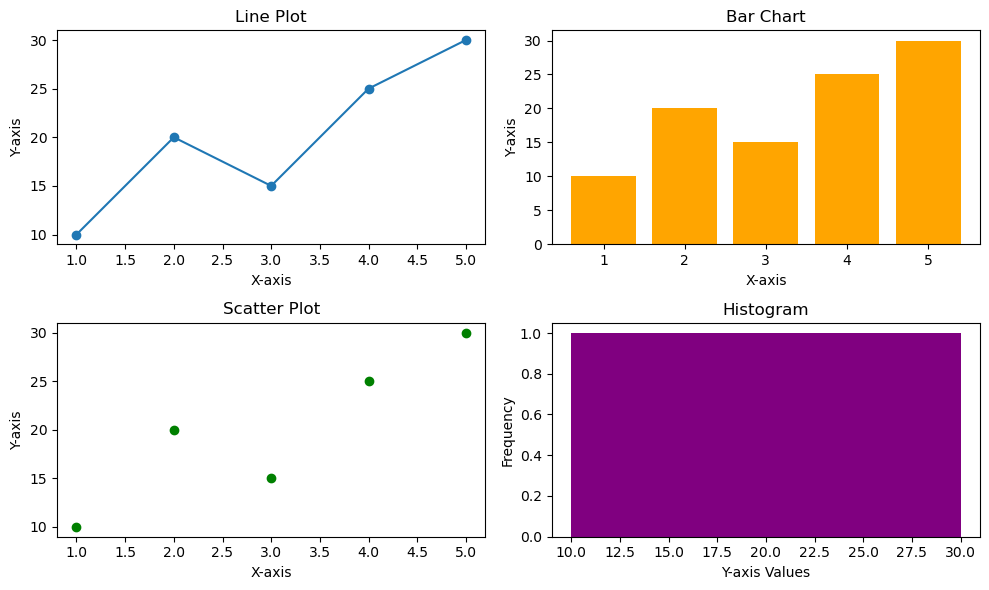

In [18]:
# 3.	Write a Python program using Matplotlib to create the following plots 
# a.	Line Plot
# b.	Bar Chart
# c.	Scatter Plot
# d.	Histogram
# Consider the data as: x = [1, 2, 3, 4, 5] y = [10, 20, 15, 25, 30]. Include proper titles and axes.
import matplotlib.pyplot as plt
x = [1, 2, 3, 4, 5]
y = [10, 20, 15, 25, 30]
# Line Plot
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(x, y, marker='o')
plt.title('Line Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
# Bar Chart
plt.subplot(2, 2, 2)
plt.bar(x, y, color='orange')
plt.title('Bar Chart')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
# Scatter Plot
plt.subplot(2, 2, 3)
plt.scatter(x, y, color='green')
plt.title('Scatter Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
# Histogram
plt.subplot(2, 2, 4)
plt.hist(y, bins=5, color='purple')
plt.title('Histogram')
plt.xlabel('Y-axis Values')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



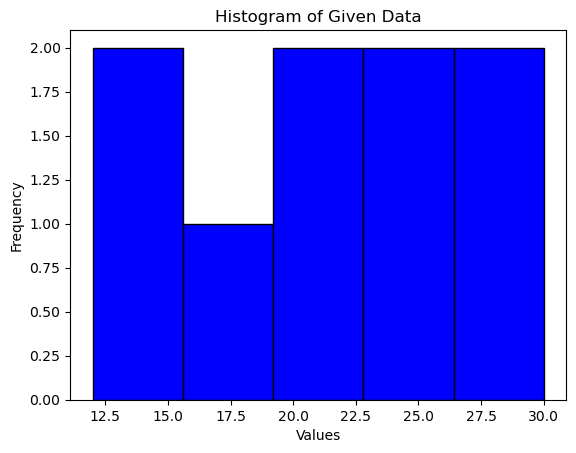

In [3]:
import matplotlib.pyplot as plt

# Given data
data = [12, 15, 18, 20, 22, 25, 25, 27, 30]

# Create histogram
plt.hist(data, bins=5 , color='blue', edgecolor='black')

# Add labels and title
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.title("Histogram of Given Data")

# Show plot
plt.show()

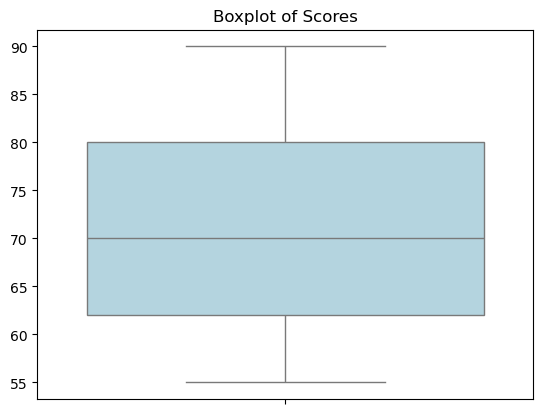

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Given data
scores = [55, 60, 62, 68, 70, 75, 80, 85, 90]

# Create boxplot
sns.boxplot(data=scores, color='lightblue')

# Add title
plt.title("Boxplot of Scores")

# Show plot
plt.show()